In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from cns.utils.assemblies import hg19
from cns.process.imputation import get_nan_segs
from cns.process.binning import get_breakpoints, bin_by_segments, add_derived
from cns.analyze.labels import plot_x_ticks, plot_cytobands

# auto reload modules
%load_ext autoreload
%autoreload 2
plt.rcParams['figure.facecolor'] = 'white'

In [3]:
data = {
    "PCAWG" : pd.read_csv("./out/PCAWG_samples.tsv", sep="\t"),
    "TCGA_hg19": pd.read_csv("./out/TCGA_hg19_samples.tsv", sep="\t"),
    "TRACERx": pd.read_csv("./out/TRACERx_samples.tsv", sep="\t"),
}
colors = ["cyan", "purple", "green"]

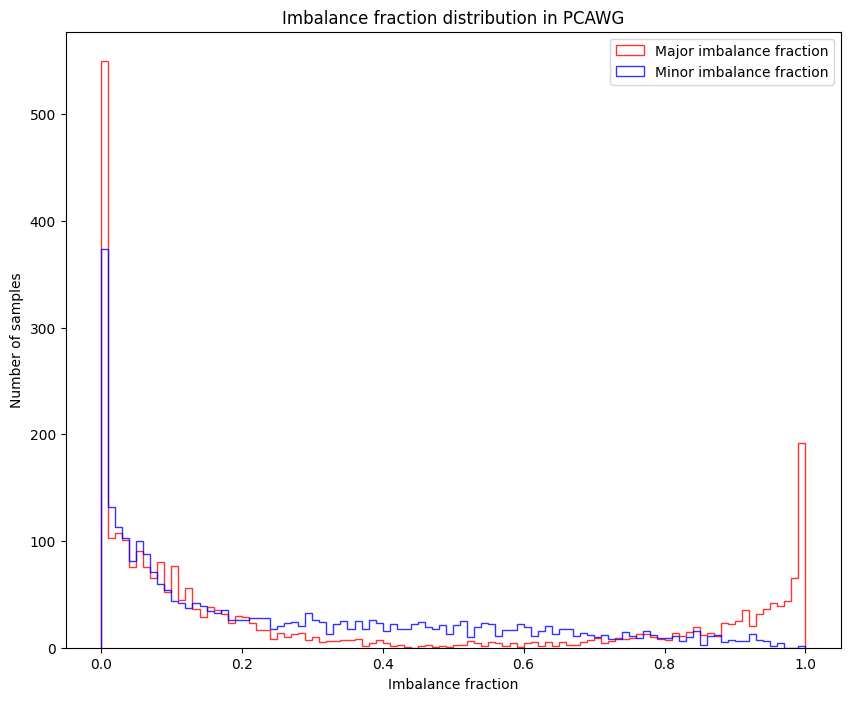

In [7]:
bins = np.arange(0, 1.01, 0.01)
fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=100)
ax.hist(data["PCAWG"]["ane_major_cn_frac_aut"], bins=bins, color="red", histtype="step", label="Major imbalance fraction", alpha=.8);
ax.hist(data["PCAWG"]["ane_minor_cn_frac_aut"], bins=bins, color="blue", histtype="step", label="Minor imbalance fraction", alpha=.8);
ax.set_ylabel ("Number of samples")
ax.set_xlabel("Imbalance fraction")
ax.set_title("Imbalance fraction distribution in PCAWG")
ax.legend()

In [8]:
data["PCAWG"].query("ane_major_cn_frac_aut <= 0.0 and ane_minor_cn_frac_aut <= 0.0").shape[0]

51

In [9]:
data["PCAWG"].query("ane_major_cn_frac_aut <= 0.01 and ane_minor_cn_frac_aut <= 0.01").shape[0]

285

In [10]:
cutoff = np.arange(0, 1.001, 0.001)
sample_count = {}
for k, v in data.items():
    sample_count[k] = []
    for i in cutoff:
        below = data[k].query(f"ane_major_cn_frac_aut <= {i} and ane_minor_cn_frac_aut <= {i}").shape[0]
        sample_count[k].append(below / v.shape[0])

Text(0.5, 1.0, 'Samples with imbalance fraction <= x')

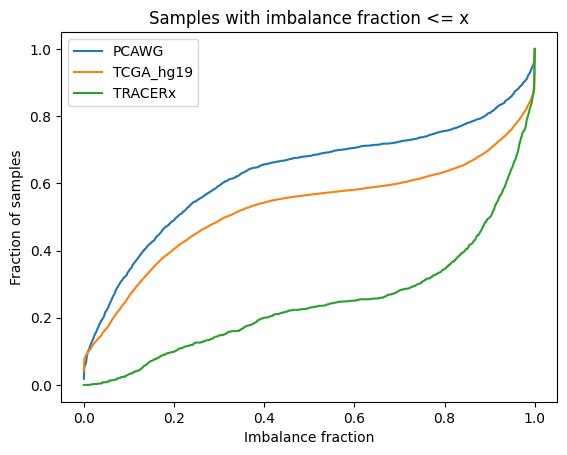

In [11]:
for k, v in sample_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with imbalance fraction <= x")

Text(0.001, 0.2, ' cutoff = 0.001')

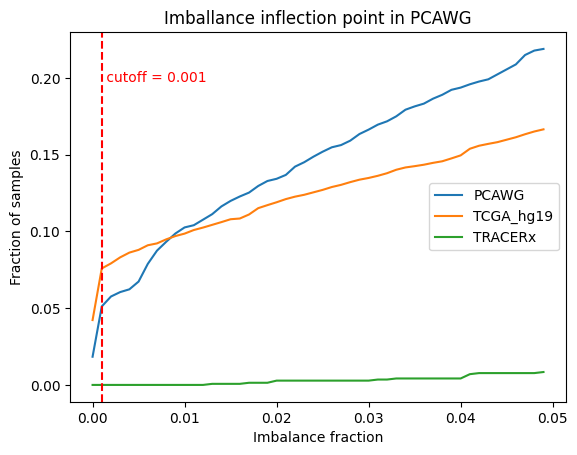

In [12]:
for k, v in sample_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)
# add a vertical line at 0.01
plt.axvline(x=0.001, color="red", linestyle="--")
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.title("Imballance inflection point in PCAWG")
plt.legend()
# add a text to the vertical line
plt.text(0.001, 0.2, " cutoff = 0.001", rotation=0, verticalalignment="center", horizontalalignment="left", color="red")

In [15]:
cutoff = np.arange(0, 1.001, 0.001)
coverage_count = {}
for k, v in data.items():
    coverage_count[k] = []
    for i in cutoff:
        below = data[k].query(f"cover_frac_aut <= {i}").shape[0]
        coverage_count[k].append(below / v.shape[0])

Text(0.5, 1.0, 'Samples with coverage fraction <= x')

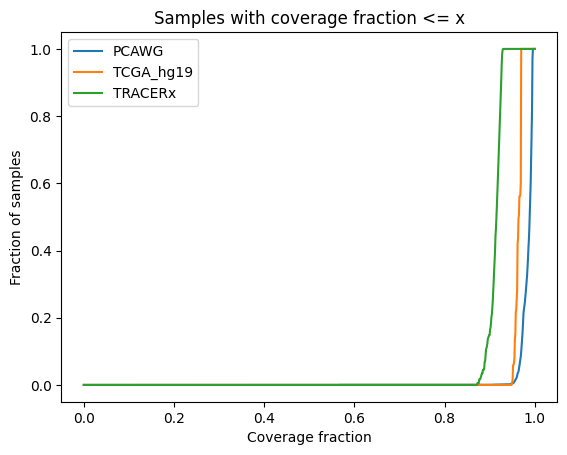

In [18]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction <= x")

Text(0.95, 0.2, ' cutoff = 0.95 ')

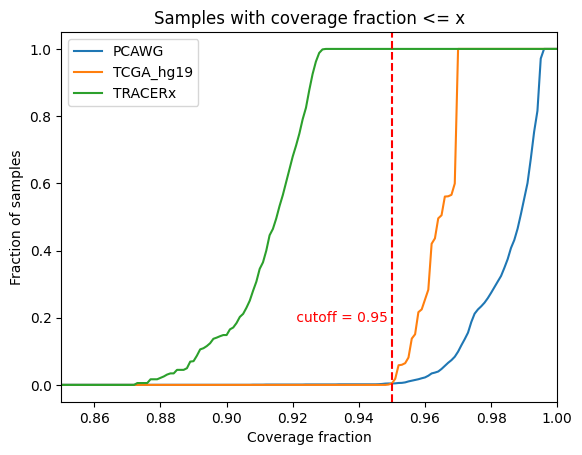

In [19]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlim(0.85, 1)
# add vertical line at .95
plt.axvline(x=0.95, color="red", linestyle="--")
plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction <= x")
# add a text to the vertical line
plt.text(0.95, 0.2, " cutoff = 0.95 ", rotation=0, verticalalignment="center", horizontalalignment="right", color="red")